#은행 마케팅 데이터 분석

##**분석 목표**

분석 데이터셋 : UC Irvine Machine Learning Repository에서 제공하는 Bank Marketing데이터 (2008~2010년 까지의 포르투갈 은행 마케팅 캠페인 데이터)

분석 데이터셋(포르투갈 은행의 마케팅 데이터)를 분석하고, 분류 모델을 구축하여 마케팅 켐페인의 효율성을 높이는 전략 도출

##목차

1. 데이터셋 살펴보기(EDA)
2. 데이터 전처리
3. 모델 선택 및 학습
4. 분석 결과 도출

##**1. 데이터셋 살펴보기(EDA)**

###a) 모듈 import/폰트 설정

In [1]:
!pip install shap

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
import time
import shap

In [3]:
#한글 폰트 설정
font_path = 'NanumGothic.ttf'       # 설치한 폰트 경로
fm.fontManager.addfont(font_path)   # 폰트 경로 추가

plt.rcParams['font.family'] = 'NanumGothic' # 사용 폰트 입력
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 사용

###b) 데이터셋 불러오기

dataFrame의 형태를 보니 첫 줄은 특징들의 모음으로 되어있고, 그 아래 행들은 특징에 맞는 데이터인듯 한데,모두 세미콜론으로 나누어져 있었다. 따라서 index X features 프레임으로 읽어오기 위해서 sep 인자를 조정해서 df를 불러왔다.

In [4]:
df = pd.read_csv('bank-additional-full.csv', sep = ';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

모든 column이 non-null이어서 dropna()를 통한 결측치 처리는 불필요하다.

###c) 데이터셋 소개

특징 | 데이터 타입 | 비고 |
|:---|:---:|---:|
| age | int | 나이(숫자형) |
| job | object | 현재 직업(ex. admin, entrepreneur, retired, student, etc) |
| marital | object | 결혼 여부(divorced, married, single, unknown) |
| default | object | 교육 수준(ex. basic.9y, illiterate, university.degree, unknown, etc) |
| housing | object | 주택 대출 여부(yes, no, unknown) |
| loan | object | 개인 대출 여부(yes, now, unknown) |
| contact | object | 연락 유형(cellular, telephone) |
| month | object | 마지막 연락 월(jan(January) ~ dec(December)) |
| day_of_week | object | 마지막 연락 요일(mon ~ fri) |
| duration | int | 마지막 연락 지속 시간(초 단위) |
| campaign | int | 캠페인 중 연락 횟수 |
| pdays | int | 이전 켐페인 후 지난 일 수 |
| previous | int | 이전 캠페인 동안 연락 횟수 |
| poutcome | object | 이전 캠페인 결과(failure, nonexistent, success) |
| emp.var.rate | float | 고용 변동률 |
| cons.price.idx | float | 소비자 물가지수 |
| cons.conf.idx | float | 소비자 신뢰지수 |
| euribor3m | float | 3개월 유리보 금리 |
| nr.emplyed | float | 고용자 수(노동 시장의 확장기/침체기) |
| y | object | **결과 라벨 : 정기 예금 가입 여부(yes, no)** |


범주형 데이터에서 클래스의 종류가 표기된 것보다 많은 경우, etc로 표시하였다.

※유리보(EURIBOR) : Euro Interbank Offered Rate : 유럽연합 내 적용되는 금리의 평균치

###d) 특징 구조 파악

원본 데이터를 건드리지 않고 데이터를 살펴보기 위해 df_eda라는 df의 copy를 만들어서 eda, 결측치/이상치 제거를 먼저 수행해보기로 결정

In [5]:
df_eda = df.copy()
df_eda.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


수치형과 범주형 column을 미리 나누어서 리스트로 지정해놓았다.

In [6]:
#수치형과 범주형 column 형식별로 리스트 지정
seq_x = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', ]
cate_x = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

###e) 수치형 특징 분석

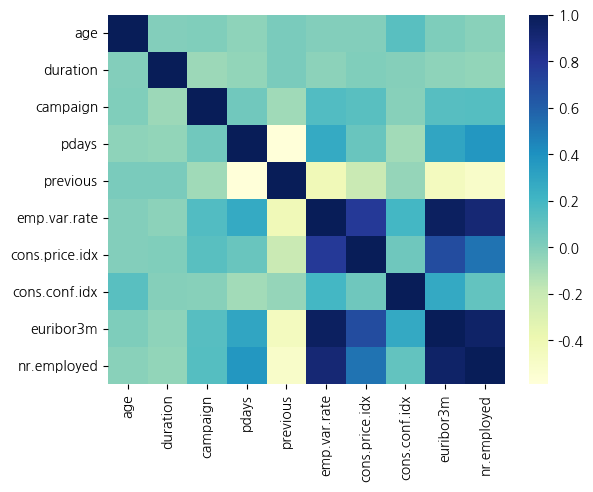

In [7]:
#상관관계 파악
seq = df_eda.select_dtypes(include='number') # 수치형 선택
corr = seq.corr(method='pearson')
sns.heatmap(corr, cmap='YlGnBu')
plt.show()

**높은 상관계수 column :**

euribor3m(유리보 금리) - nr.employed

euribor3m - emp.var.rate

emp.var.rate - nr.emplyed

emp.var.rate - cons.price.idx

euribor3m column과 emp.var.rate는 다중공선성 문제를 방지하기 위해 drop

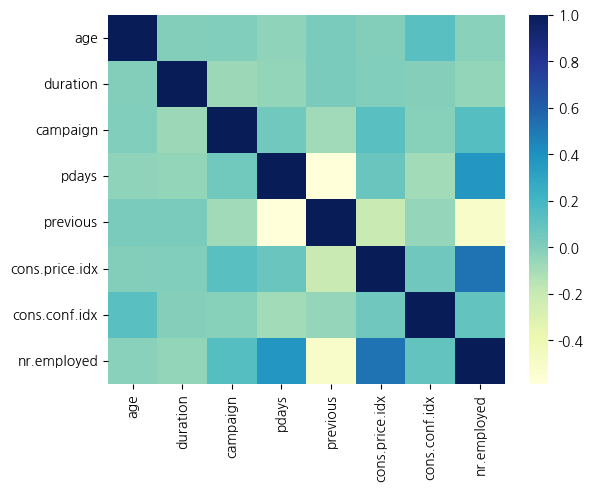

In [8]:
df_eda.drop(columns = ['euribor3m', 'emp.var.rate'], inplace = True)
seq_x.remove('euribor3m')
seq_x.remove('emp.var.rate')
seq = df_eda.select_dtypes(include='number') # 수치형 선택
corr = seq.corr(method='pearson')
sns.heatmap(corr, cmap='YlGnBu')
plt.show()

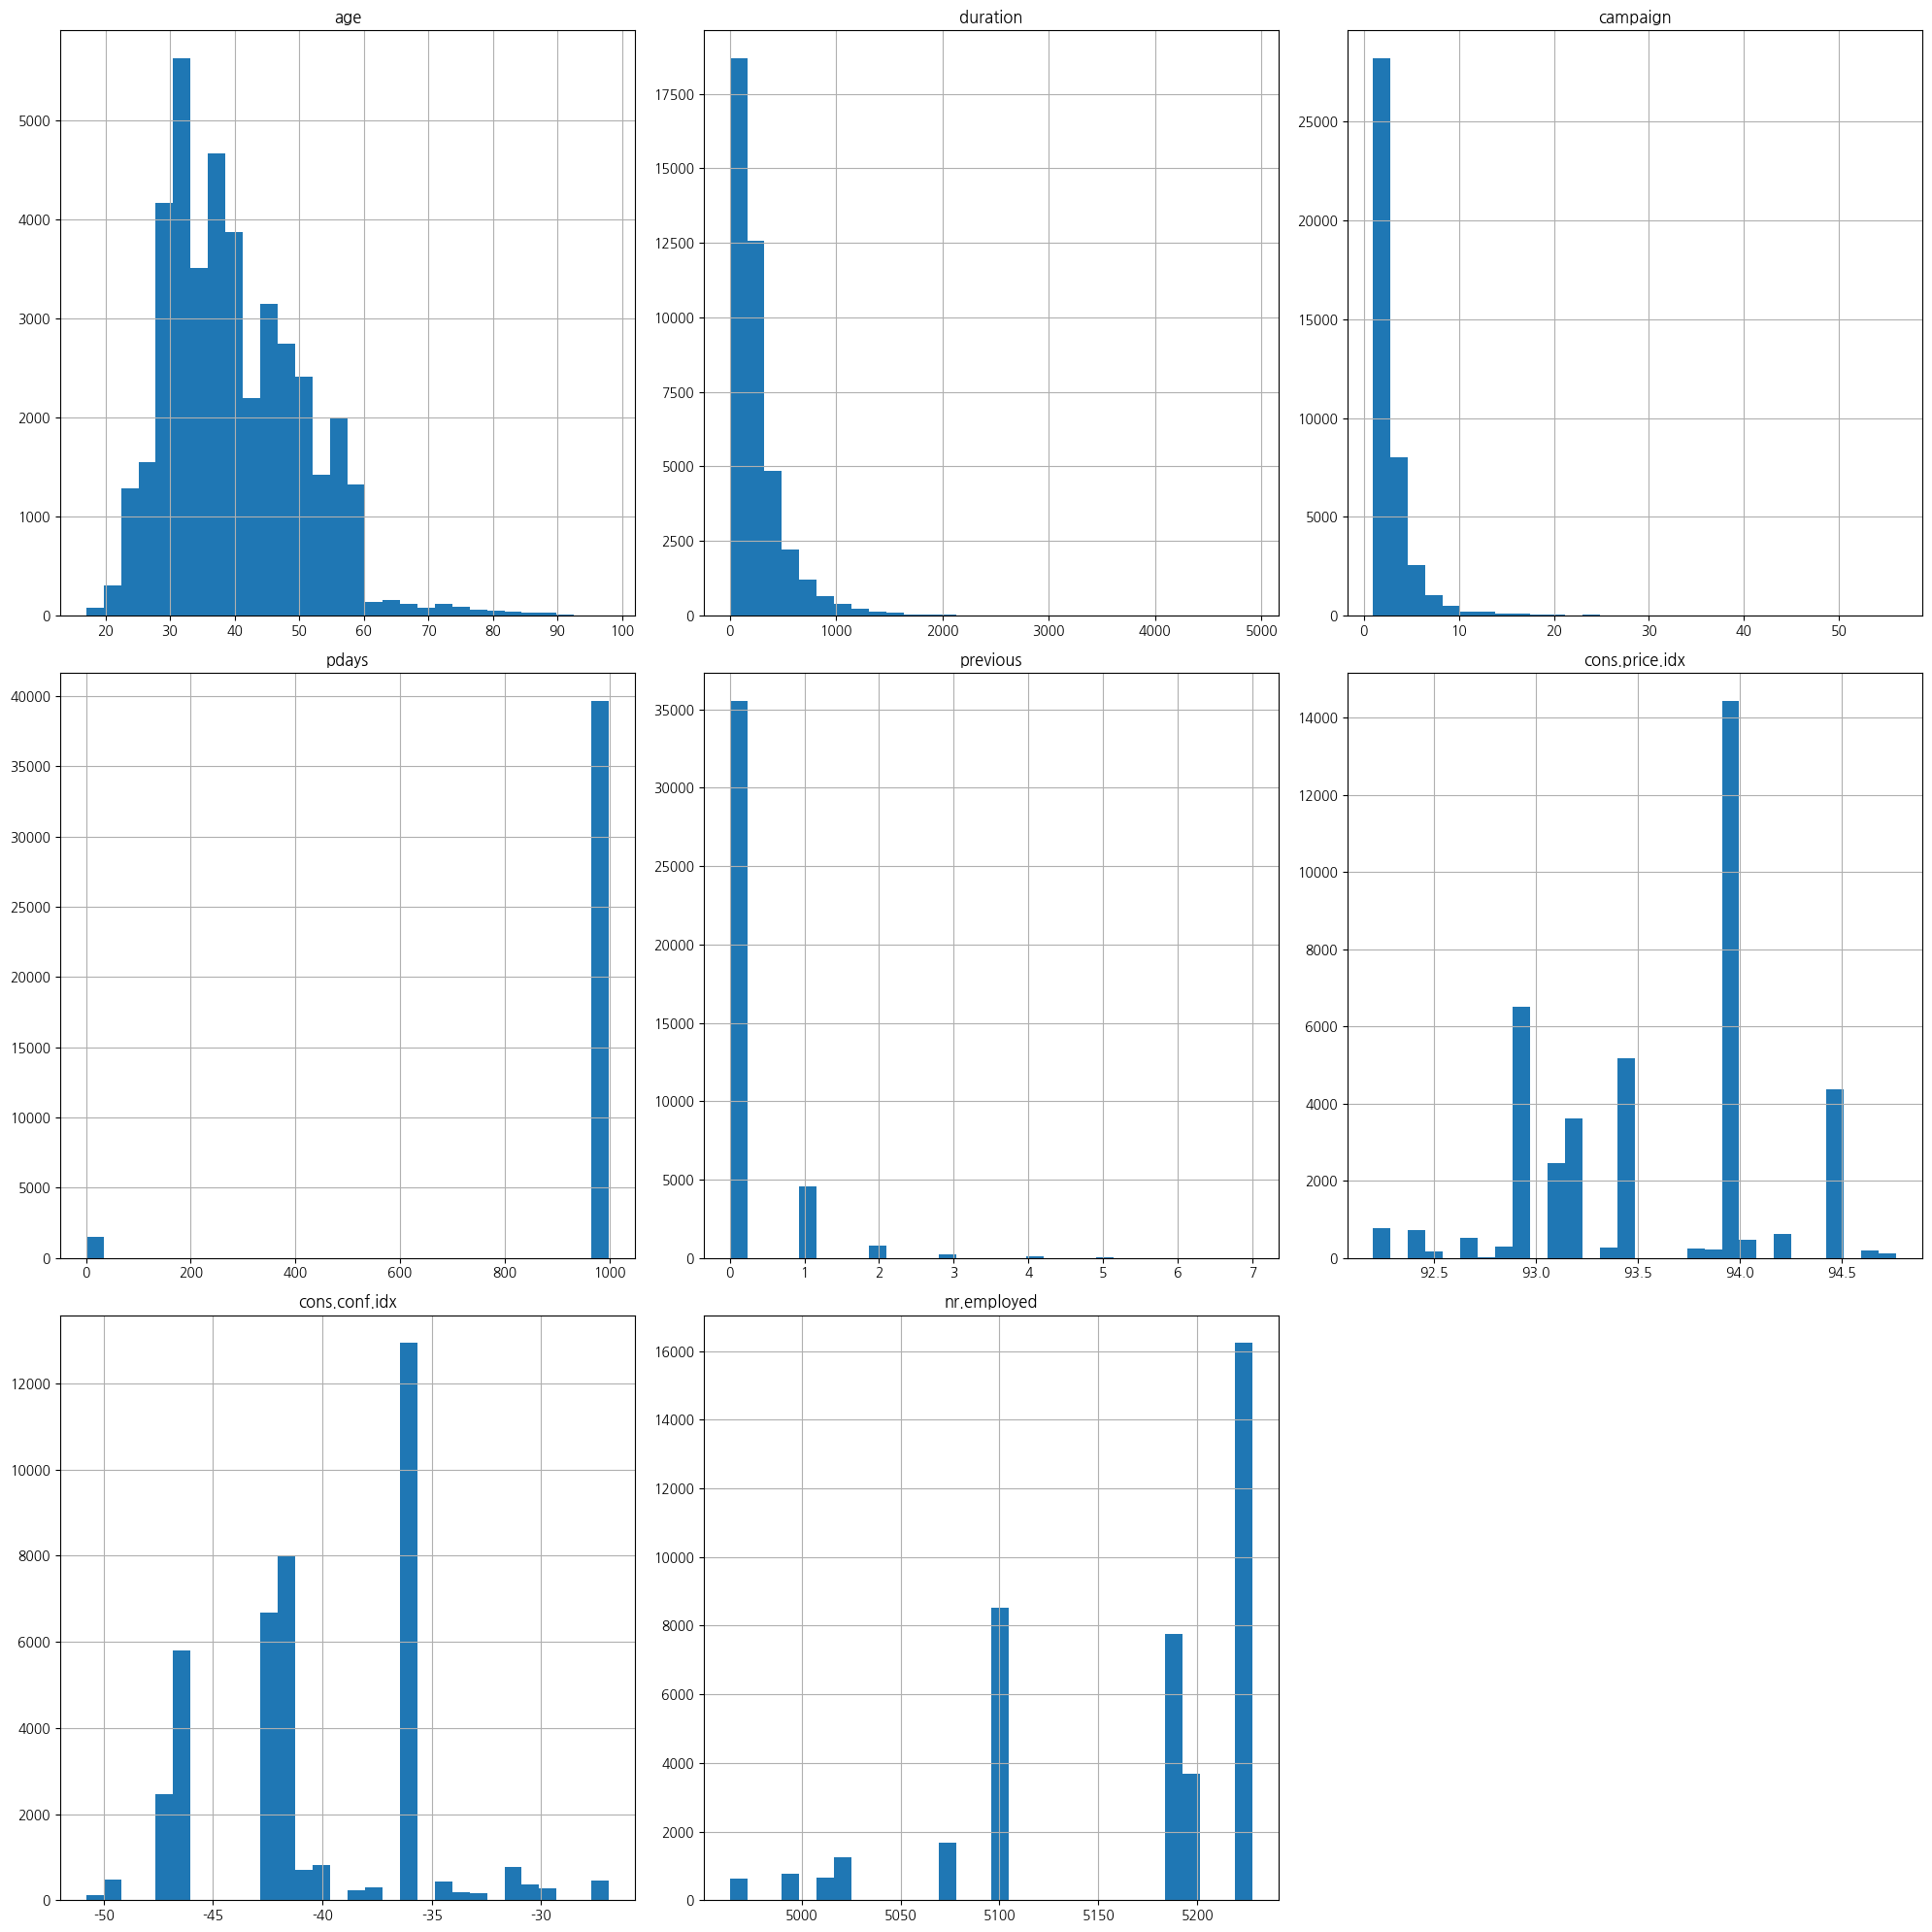

In [9]:
#숫자형 데이터 히스토그램 생성
df_eda.hist(bins = 30, figsize = (20,20))
plt.tight_layout()
plt.show()

수치형 데이터에 대해 히스토그램과 value_counts()를 통해 분포를 파악했다.

**pdays** : 약 7일이 넘어가면 999로 모두 수렴하는 형태를 보인다. 999의 경우 이전 켐페인을 진행하지 않은 것이라고 판단해 이전 캠페인 진행여부에 따른 0/1 라벨링을 진행하여 범주형 데이터로 변환 후 삭제하는 것이 맞다고 판단했다.

previous : 이전 캠페인 연락 횟수가 0~1 일인 경우에 가장 편향되어있었다.

duration, campaign : 연속적 데이터이지만 값들이 왼쪽에 몰려있어 로그 변환을 고려해볼만 함. 로그변환 전과 이후의 모델의 예측 척도를 보고 판단 예정

####pdays column 처리

In [10]:
#pdays column apply -> previous_exist 열 추가
df_eda['previous_exist'] = df_eda['pdays'].apply(lambda x : 0 if x == 999 else 1)
df_eda.drop(columns = ['pdays'], inplace = True)
seq_x.remove('pdays')
cate_x.append('previous_exist')

pdays column에서 999값을 가질 경우 0, 그렇지 않을 경우 1을 가지는 previous_exist feature을 만든 후 pdays 열을 drop했다. 라벨 인코딩을 완료하여서 추후 previous_exist행에 대해 인코딩은 필요없을듯 하다.

####Duration Column 처리

bank-additional-names.txt 발췌

> this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.



해석/설명 : 데이터셋을 제공한 기관에서 데이터의 설명을 동봉한 txt파일(bank-additional-names.txt)에 따르면 duration column은 output Target에 지대한 영향을 미친다고 한다. duration = 0 이면 거의 항상 y = "no'가 되기 때문에, duration 은 단순히 성능 비교용으로만 제공된 변수이며, **현실적인 예측 모델을 만들려면 이 변수는 제거해야 한다고 한다.**

따라서 데이터 누수 이슈를 방지하기 위해서 duration column은 drop하기로 결정했다.

In [11]:
#Duration Drop
df_eda.drop(columns = ['duration'], inplace = True)
seq_x.remove('duration')

###f) 범주형 특징 분석

범주형 특징들 중 unknown이라고 답한 답변들에 대한 처리를 하기 위해 object 자료형을 가진 column들에 한해 barplot으로 시각화했다.

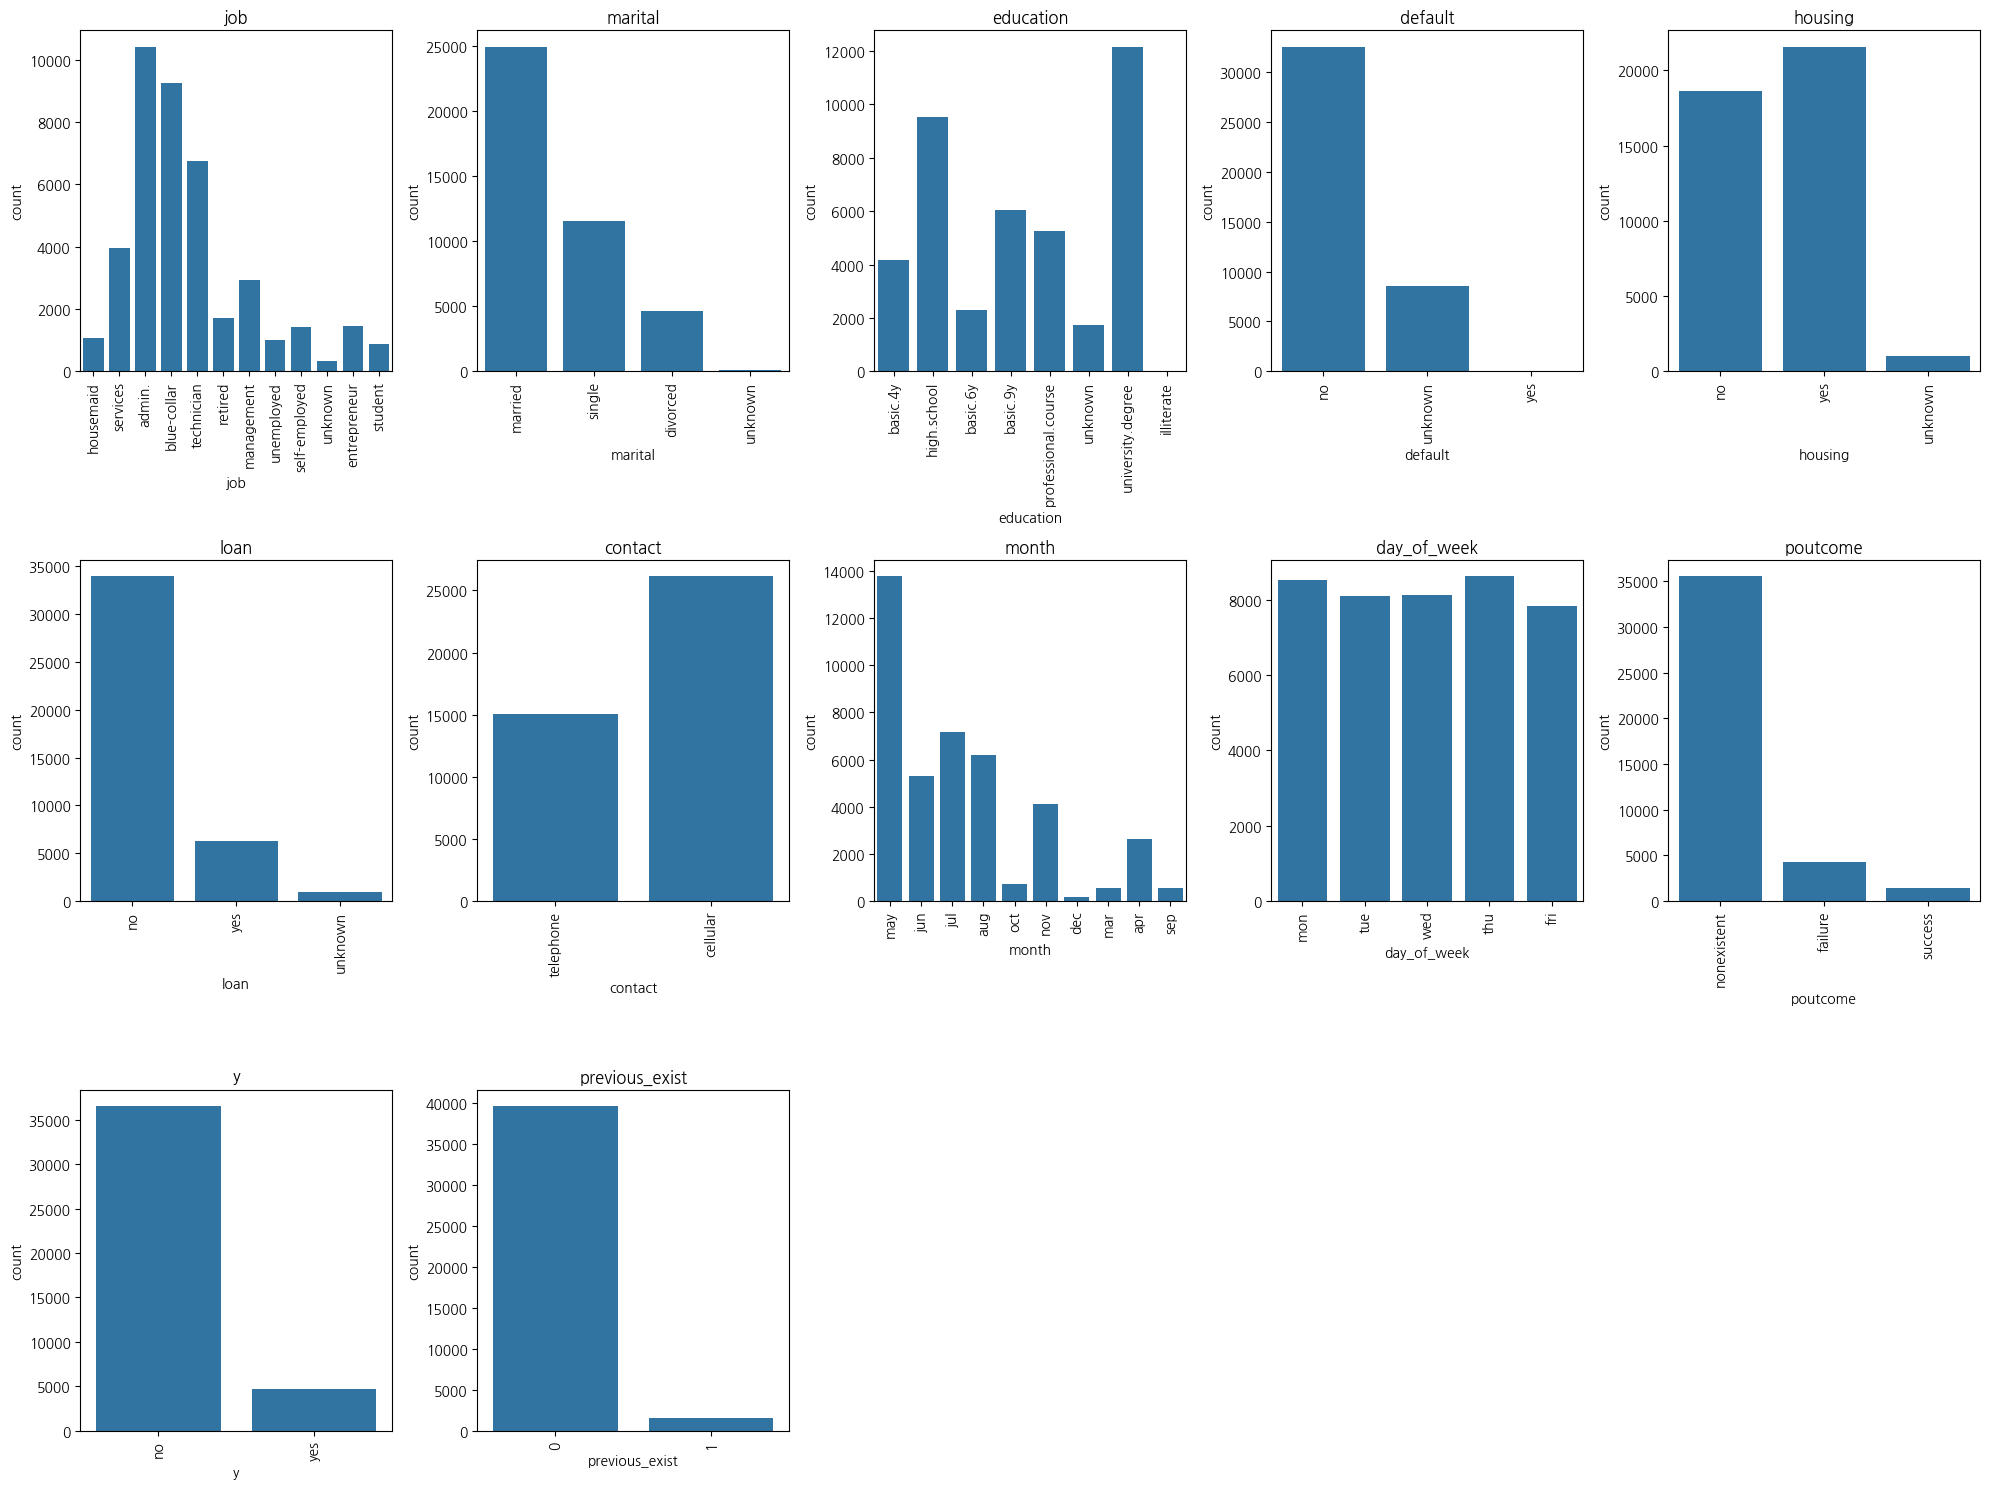

In [12]:
#범주형 column 시각화

rows,cols = 3, 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 15))

for i in range(len(cate_x)):
    row = i // cols
    col = i % cols
    sns.countplot(data=df_eda, x = cate_x[i], ax=axes[row, col])
    axes[row, col].set_title(cate_x[i])
    axes[row, col].tick_params(axis='x', rotation=90)

for j in range(len(cate_x), rows * cols):
    fig.delaxes(axes[j // cols, j % cols])

plt.tight_layout()
plt.show()

####인코딩 방식 결정

범주형 countplot을 보았을 때, yes/no로 이루어진 column은 ont-hot encoding을 진행하는 것이 적절하다고 생각했고, 그렇지 않은 column은 target encoding을 적용하기로 결정했다.

one-hot : default, housing, loan


target : job, marital, education, contact, month, day_of_week, poutcome

####결측치 처리

unknown이란 답이 있는 column들에는 job, marital, education, default, housing, loan이 있었다.

job, martial, loan, housing : unknown이란 답변에 대해서는 수가 적어 결측치로 인식, **결측치 처리하기로 결정**했다.

default, education : 이 특징들에서의 unknwon 답변은 무시하지 못할 숫자라서 결측치라고 표현하기엔 **일부러 답변을 피했다고 분석할 수도 있다고 생각**해서 unknown 답변 자체를 유의미하게 활용할 수 있을 것 같아 **결측치라고 판단하지 않고 처리**하지 않기로 결정했다.

In [13]:
drop_cols = ['job', 'marital', 'loan', 'housing']
df_eda = df_eda[df_eda[drop_cols] != 'unknown']

###EDA 결론

drop할 column : euribor3m, emp.var.rate, duration

duration, campaign : 모델 결과에 따라 로그 변환 유무 결정

pdays : 범주형으로 apply하여 previous_exist열 추가후 drop


default, housing, loan : one-hot encoding 사용

job, marital, education, contact, month, day_of_eek, poutcome : target encoding 사용

결측치 처리(unknown) column : job, marital, loan, housing


##**2. 데이터 전처리**

###전처리 Class 생성

추후에 test데이터셋을 받아서 예측해야하는 일이 발생할 가능성과, 가독성을 높이기 위해 데이터를 전처리할 수 있는 Class를 생성(EDA 결론 참고하여 구현)

In [14]:
class DataProcessor :
  def __init__(self):
    self.one_hot_cols = ['default', 'housing', 'loan'] #one-hot encoding할 columns
    #target-encoding할 columns
    self.target_cols = ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome']
    self.log_cols = ['duration', 'campaign']
    self.unknown_cols = ['job', 'marital', 'loan', 'housing']
    self.Targetenc = TargetEncoder(smooth = 10)
    self.Onehotenc = OneHotEncoder(sparse_output = False, handle_unknown='ignore') # handle_unknown for robustness

    #추후 Target-Encoding된 데이터를 inverse 하기 위한 mapping 정보 저장
    self.mappings = {}

  def process_data(self, df):
    df = df.copy() # Operate on a copy to avoid modifying the original df

    # Drop columns as decided in EDA
    df = df.drop(columns = ['euribor3m', 'emp.var.rate', 'duration'])

    # Process 'pdays' column
    df['previous_exist'] = df['pdays'].apply(lambda x : 0 if x == 999 else 1)
    df.drop(columns = ['pdays'], inplace = True)

    #df[log_cols] = df[log_cols].apply(lambda x : np.log1p(x))    #추후 로그변환시에 사용할 row

    # Handle 'unknown' values in specified columns by dropping rows
    for col in self.unknown_cols:
      df = df[df[col] != 'unknown']

    return df

#train 데이터 전처리 함수 정의
  def train_encoding(self, df) :
    df = self.process_data(df)
    #라벨 데이터 라벨 인코딩 yes : 1, no : 0
    df['y'] = df['y'].apply(lambda x : 1 if x == 'yes' else 0)

    #TargetEnc
    self.Targetenc.fit(df[self.target_cols], df['y'])
    encoded = pd.DataFrame(self.Targetenc.transform(df[self.target_cols]),
                           columns = self.target_cols,
                           index = df.index)
    for col in self.target_cols :
      temp = pd.DataFrame({
        'category': df[col],
        'value': encoded[col].round(6)
      })
      self.mappings[col] = (temp.drop_duplicates().set_index('category')['value'].to_dict())
    df[self.target_cols] = encoded

    #One-HotEnc
    self.Onehotenc.fit(df[self.one_hot_cols])
    one_hot_data = self.Onehotenc.transform(df[self.one_hot_cols])
    one_hot_df = pd.DataFrame(one_hot_data, columns=self.Onehotenc.get_feature_names_out(self.one_hot_cols), index=df.index)
    df = df.drop(columns = self.one_hot_cols)
    df = pd.concat([df, one_hot_df], axis = 1)

    df = df.dropna()
    return df

#test 데이터 전처리 함수 정의
  def test_encoding(self, df) :
    df = self.process_data(df)
    #Target Enc
    encoded = pd.DataFrame(self.Targetenc.transform(df[self.target_cols]),
                           colums = self.target_cols,
                           index = df.index)
    for col in self.target_cols :
      temp = pd.DataFrame({
        'category': df[col],
        'value': encoded[col].round(6)
      })
      self.mappings[col] = (temp.drop_duplicates().set_index('category')['value'].to_dict())
    df[self.target_cols] = encoded

    #One-HotEnc
    one_hot_data = self.Onehotenc.transform(df[self.one_hot_cols])
    one_hot_df = pd.DataFrame(one_hot_data, columns=self.Onehotenc.get_feature_names_out(self.one_hot_cols), index=df.index)
    df = df.drop(columns = self.one_hot_cols)
    df = pd.concat([df, one_hot_df], axis = 1)

    df = df.dropna()
    return df

#TargetEncoder Decoding 함수 정의
  def inverse_target_encoding(self, df) :
    for col in self.target_cols:
        mapping = self.mappings[col]
        inv_map = {round(v,6): k for k, v in mapping.items()}
        df[col] = df[col].round(6).map(inv_map)
    return df

추가로 TargetEncoder은 따로 inverse하는 메소드를 가지고 있지 않기에, mapping에 인코딩된 값들을 저장하여서 inverse하는 함수를 정의했다.

###데이터 전처리 진행

위에서 정의한 클래스를 이용해 테스트 데이터를 전처리했다. 원본 데이터를 건드리지 않기 위해 copy()를 통해 복사하여 전처리를 진행하였다.

In [15]:
processor = DataProcessor()

processed_df = processor.train_encoding(df)


##**3. 모델 선택 및 학습**

###비교 모델/평가지표 소개

적절한 모델 선택과 최적의 예측률을 위해서 각 모델을 학습시 평가지표를 도출하고, 제일 우수한 평가지표를 보인 모델을 선택하기로 했다.

선택 후보 모델 :



*   LogisticRegression(로지스틱 분류 모델)


*   SVM(Support Vector Machine)
*   RandomForest(트리-배깅 활용 모델)


*   GradientBoosting(경사하강법 이용 부스팅 모델)
*   HistGradientBoostingRegressor(Leaf-wise 방식 활용 모델)





활용 평가지표 :



*   정확도(accuracy)
*   f1 score


*   RMSE
*   ROC_AUC Score


*   측정 시간







In [16]:
#테스트, train 데이터 split

X = processed_df.drop(columns = ['y'])
Y = processed_df['y'].to_numpy()

train_X, test_X, train_Y, test_Y = train_test_split(X, Y,
                                                      test_size=0.2,
                                                      random_state=42)

###모델 비교

In [17]:
#결과를 저장할 리스트 생성
res = []

models = {
    'LogisticRegression' : LogisticRegression(),

    'SVM' : svm.SVC(kernel = 'rbf', C = 10.0, max_iter = 100, probability = True),

    'RandomForest' : RandomForestClassifier(
                                            n_estimators = 30,
                                            criterion = 'entropy',
                                            max_depth = 20,
                                            max_samples = 0.7,
                                            random_state = 42
                                            ) ,
    'GradientBoosting' : GradientBoostingClassifier(
                                                    n_estimators = 30,
                                                    max_depth = 3,
                                                    learning_rate = 0.2,
                                                    random_state = 42
                                                    ),
    'HistGradientBoosting' : HistGradientBoostingClassifier(
                                                            max_depth = 6,
                                                            l2_regularization = 0.1,
                                                            max_iter = 1000,
                                                            learning_rate = 0.1,
                                                            max_bins = 255 ,
                                                            random_state = 42
                                                            )
}

for name, model in models.items():
  start = time.time()
  model.fit(train_X, train_Y)       #각각의 모델 학습
  pred = model.predict(test_X)      #학습된 모델로 test데이터 predict
  pred_proba = model.predict_proba(test_X)[:, 1] #roc_auc 점수를 위한 정답 클래스에 대한 확률

  #성능지표 도출해 저장
  accuracy = accuracy_score(test_Y, pred)
  f1 = f1_score(test_Y, pred, average = 'binary')
  roc_auc = roc_auc_score(test_Y, pred_proba)
  rmse = np.sqrt(mean_squared_error(test_Y, pred))
  end = time.time()


  res.append({
    'model' : name,
    'accuracy' : accuracy,
    'f1' : f1,
    'roc_auc' : roc_auc ,
    'rmse' : rmse,
    'time(seconds)' : end - start
  })
  print(f'{name} : accuracy : {accuracy}, roc_auc : {roc_auc}, f1 : {f1}, rmse : {rmse}, time : {end - start}')





/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression : accuracy : 0.8980027634719256, roc_auc : 0.7615682505244519, f1 : 0.24953789279112754, rmse : 0.31937006204100343, time : 2.984661102294922


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM : accuracy : 0.1278733827408617, roc_auc : 0.7400721869042586, f1 : 0.11632938780705104, rmse : 0.9338771960269392, time : 11.767390727996826
RandomForest : accuracy : 0.8964954151488507, roc_auc : 0.7769603330966984, f1 : 0.36906584992343033, rmse : 0.32172128442356646, time : 2.6981523036956787
GradientBoosting : accuracy : 0.9032784826026881, roc_auc : 0.8065489076246919, f1 : 0.36258278145695366, rmse : 0.31100083182736327, time : 2.0791232585906982
HistGradientBoosting : accuracy : 0.9021479713603818, roc_auc : 0.8112055611833867, f1 : 0.36718115353371245, rmse : 0.31281308898385013, time : 0.6036677360534668


성능지표의 결과값을 가독성을 위해서 DataFrame으로 바꾸어서 표 형태로 볼 수 있도록 처리했다.

In [18]:
#DataFrame 변환
res_df = pd.DataFrame(res)
res_df.set_index('model', inplace = True)

#가장 우수한 성능지표를 bold처리하기 위해 함수 정의
def highlight_max(s):
    is_max = s == s.max()
    return ['font-weight: bold' if value else '' for value in is_max]

def highlight_min(s):
  is_min = s == s.min()
  return ['font-weight: bold' if value else '' for value in is_min]

res_df = res_df.style.apply(highlight_max, subset = ['accuracy', 'f1', 'roc_auc'],axis = 0)
res_df = res_df.apply(highlight_min, subset = ['rmse', 'time(seconds)'], axis = 0)

res_df

,accuracy,f1,roc_auc,rmse,time(seconds)
model,,,,,
LogisticRegression,0.898003,0.249538,0.761568,0.319370,2.984661
SVM,0.127873,0.116329,0.740072,0.933877,11.767391
RandomForest,0.896495,0.369066,0.776960,0.321721,2.698152
GradientBoosting,0.903278,0.362583,0.806549,0.311001,2.079123
HistGradientBoosting,0.902148,0.367181,0.811206,0.312813,0.603668




*   SVM 모델의 경우에는 데이터 스케일링이 이루어지지 않아 낮은 성능지표를 보였다.
*   LogisticRegression 모델의 경우에는 다른 앙상블 모델보다 다소 낮은 f1-score를 보였다.


*   RandomForest, Gradient Boosting, HistGradientBoosting 모델의 경우에는 모델들이 비슷한 성능지표를 보였지만 다른 모델에 비해 HistGradientBoosting 모델이 시간이 압도적으로 덜 걸려서, 효율적인 예측이 가능하다고 판단했다.


**→ 최종 예측 모델은 모든 성능지표에서 가장 나은 점을 보인 HistGradientBoosting 모델로 결정하게 되었다.**







##**4. 분석 결과 도출**

트리 기반 모델이기 때문에 치환 중요도, Shap 분석을 통해서 특징별 분석을 진행했다.

####모델 학습

In [19]:
#HistGradientBoosting 모델을 활용하여 학습

final_model = HistGradientBoostingClassifier(max_depth = 6,
                                             l2_regularization = 0.1,
                                             max_iter = 1000,
                                             learning_rate = 0.1,
                                             max_bins = 255 ,
                                             random_state = 42)
final_model.fit(train_X, train_Y)
predicts = final_model.predict(test_X)
#성능지표는 위에서 확인했기에 생략

###특성 중요도 분석

먼저 전체적인 특성의 중요도를 보기 위해서 permutation Importance를 먼저 확인해보기로 했다.

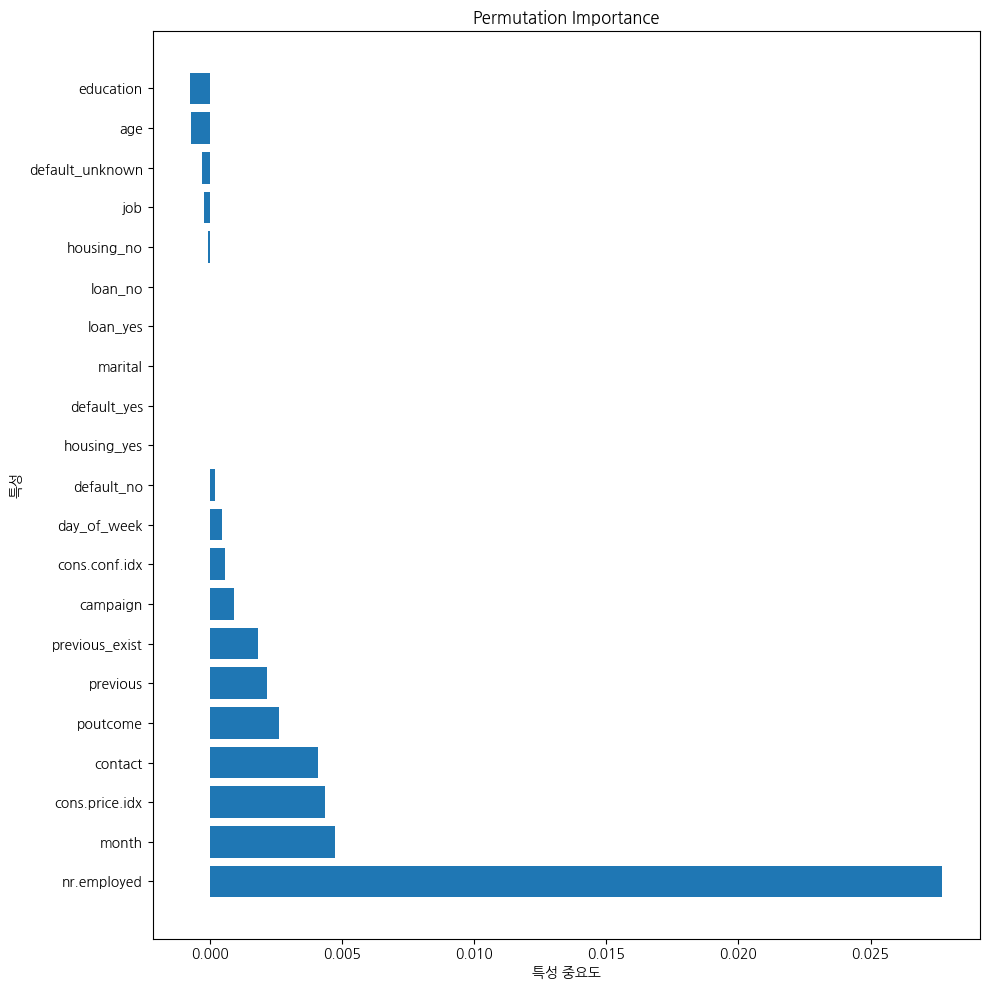

In [20]:
#특성 중요도 분석
result = permutation_importance(final_model,
                                test_X,
                                test_Y,
                                n_repeats=10,
                                random_state=42)

importances = result.importances_mean
sorted_importances = np.argsort(importances)[::-1]
features = test_X.columns

plt.figure(figsize = (10,10))
plt.title("Permutation Importance")
plt.barh(range(test_X.shape[1]), importances[sorted_importances])
plt.yticks(range(test_X.shape[1]), features[sorted_importances])
plt.xlabel('특성 중요도')
plt.ylabel('특성')
plt.tight_layout()
plt.show()

- 고용자 수에 따른 예측값이 큰 영향을 보여, 고용시장의 변화에 따라 예금 가입에 영향이 있다고 막연하게 볼 수 있는데, 뒤따르는 cons_price.idx 역시 경제 상황에 면밀한 관계가 있는 척도이다. month 특징도 큰 관여를 하고 있는 것을 보아, **2008~2010년 월에 따른 포르투갈 경제 상황**을 참고하면 좋겠다고 생각이 든다.

- 또한 중요도 양수를 보이고 있는 previous_exist, poutcome, previous 특징들은 이전에 예금 가입을 한 적이 있는 사람들에 관한 데이터인데, 예금상품 자체가 이율이 괜찮았을까? 그래서 다시 들게 되었을까 ? 아니면 그 반대일까 ? shap 분석을 통해서 비례관계인지, 반비례 관계인지 확인해볼 필요가 있겠다고 생각이 든다.

- 사람의 개인적인 특성인 age/marital/education의 경우에는 크게 중요도가 없는 것을 보아 고객의 특성보다는 경제상황/이전 상품 경험에 조금 더 초점을 맞추고 생각해볼 수도 있겠다고 생각했다

###SHAP Value 분석

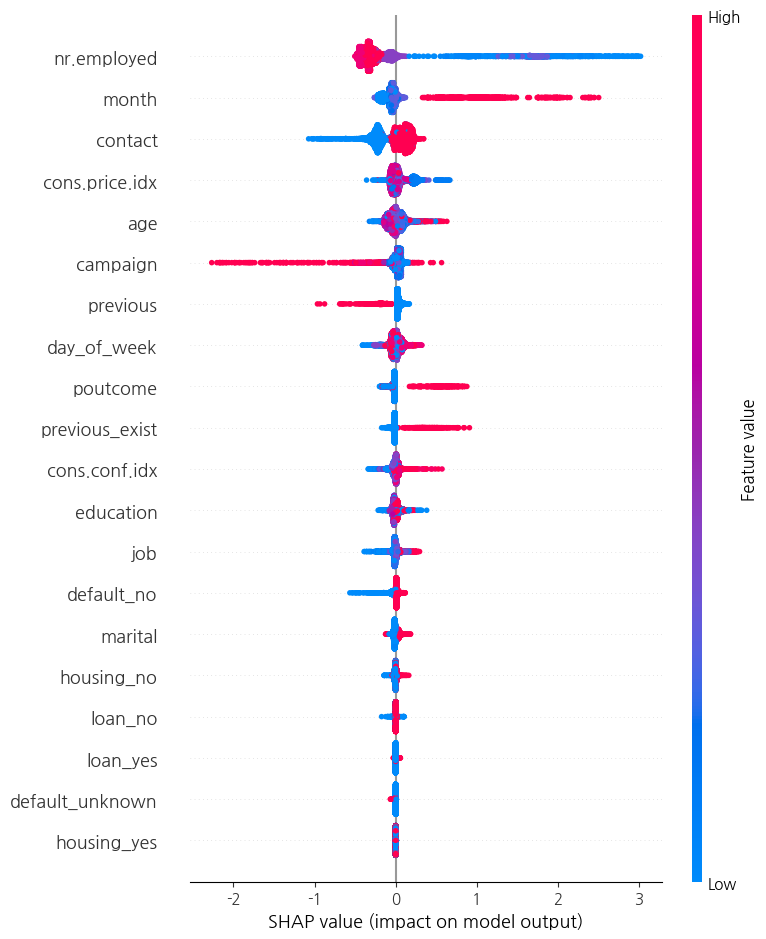

In [21]:
explainer = shap.Explainer(final_model)
shap_values = explainer.shap_values(test_X)
shap.summary_plot(shap_values, test_X, feature_names=test_X.columns)


####고용자 수 분석

모델에 가장 크게 기여하는 특성인 nr.employed 특성은, 낮아질수록 shapValue가 올라가는 것을 볼 수 있다.

**고용자 수가 감소할 수록 예금을 들 확률이 올라간다 !**
그렇다면 고용자수가 왜 감소할까 ? 언제 감소할까 ? 이에 대해 마케팅 담당자가 할 수 있는 일이 있을까 ?를 분석해보자

In [22]:
test_X.shape

(7961, 21)

In [23]:
#데이터 값으로 분석하기 위해 먼저 DataFrame 복구
#one-hot inverse
test_X_df = pd.DataFrame(test_X)
# encoded_feature_names = processor.Onehotenc.get_feature_names_out()
# encoded_data = test_X_df[encoded_feature_names]
# decoded_data = processor.Onehotenc.inverse_transform(encoded_data)
# test_X_df[processor.one_hot_cols] = decoded_data

#target inverse
test_X_df = processor.inverse_target_encoding(test_X_df)

In [24]:
print(test_X_df.columns)

Index(['age', 'job', 'marital', 'education', 'contact', 'month', 'day_of_week',
       'campaign', 'previous', 'poutcome', 'cons.price.idx', 'cons.conf.idx',
       'nr.employed', 'previous_exist', 'default_no', 'default_unknown',
       'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes'],
      dtype='object')


먼저 고용자수와 관련되어 있어 보이는 column들부터 dependence plot을 만들어 분석해보기로 했다. 불경기인지 아닌지를 볼 수 있는 column들로는 cons.price.idx(소비자 물가 지수), cons.conf.idx(소비자 신뢰지수)가 있겠다.

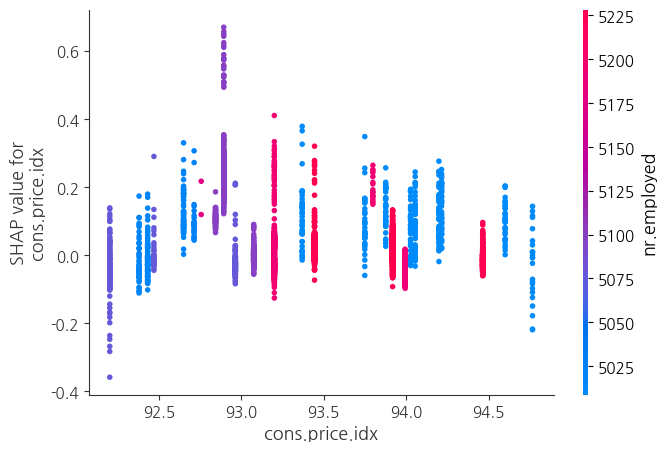

In [25]:
shap.dependence_plot('cons.price.idx', shap_values, test_X_df, interaction_index = 'nr.employed')

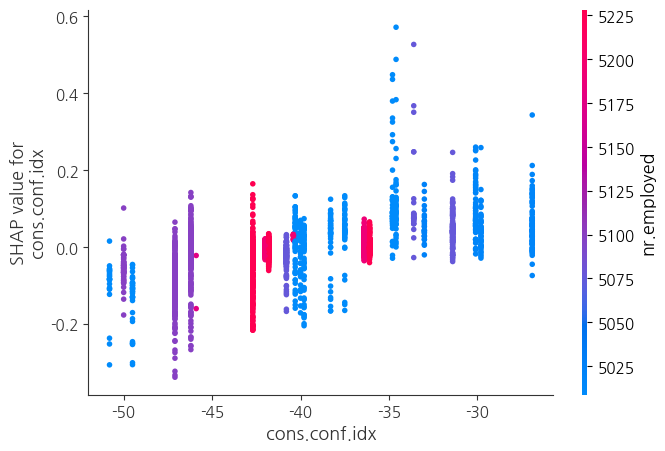

In [26]:
shap.dependence_plot('cons.conf.idx', shap_values, test_X_df, interaction_index = 'nr.employed')

소비자 물가지수와 소비자 신뢰지수가 큰 관련이 있어보이진 않는다.. 경제 상황을 볼 수 있는 변수가 뭐가 있을까 ? 하고 고민하다가 drop했던 column인 유리보 금리(euribor3m)와 고용 변동률(emp.var.rate)가 생각났다.

노동자 수와 상관계수가 높았던 것으로 보아 밀접한 관련이 있을 것 같았고, 테스트 데이터셋으로 SHAP분석을 할 순 없지만 원본 데이터를 복사해와 상관관계를 분석하는 용도로 사용했다.

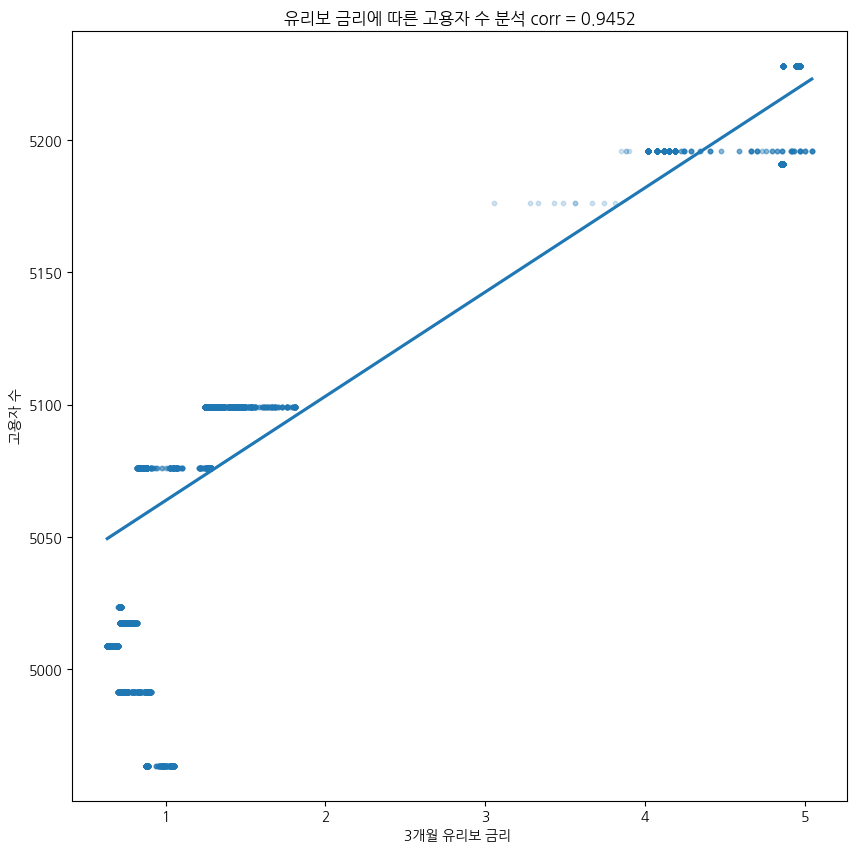

In [27]:
df_analyze = df.copy()

plot_x = df_analyze['euribor3m']
plot_y = df_analyze['nr.employed']

corr = plot_x.corr(plot_y)

plt.figure(figsize = (10,10))
sns.regplot(x = plot_x, y = plot_y, scatter_kws={'alpha':0.2, 's':10})
plt.xlabel('3개월 유리보 금리 ')
plt.ylabel('고용자 수')
plt.title(f'유리보 금리에 따른 고용자 수 분석 corr = {corr:.4f}')
plt.show()

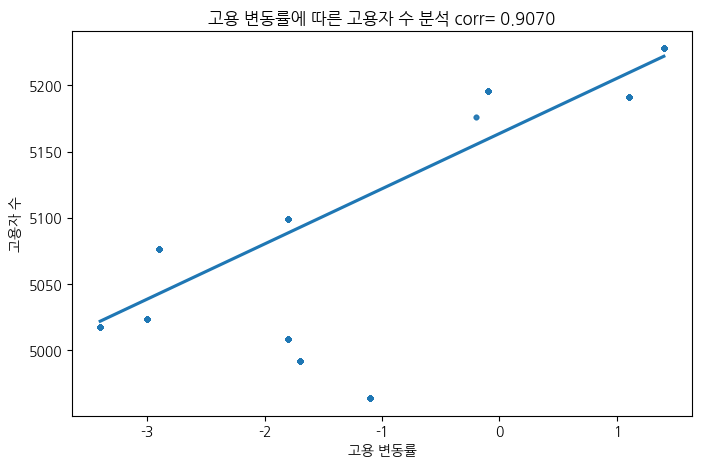

In [28]:
plot_x = df_analyze['emp.var.rate']
plot_y = df_analyze['nr.employed']

corr = plot_x.corr(plot_y)

plt.figure(figsize = (8,5))
sns.regplot(x = plot_x, y = plot_y, scatter_kws={'alpha':0.2, 's':10})
plt.xlabel('고용 변동률')
plt.ylabel('고용자 수')
plt.title(f'고용 변동률에 따른 고용자 수 분석 corr= {corr:.4f}')
plt.show()

-당연하게도 상관관계가 높은 column들을 모았기에 비례관계인 것은 명확하지만, 그래도 고용자 수가 증가하고 감소하는 원인에 고용 변동률과 3개월 유리보 금리가 있다는 것을 알 수 있었다.

##### **그런데 왜 ?**

 경험적으로 생각했을 때, 고용자 수가 줄어들면 벌어들이는 돈이 적어질테고, 그렇다보면 수중에 있는 돈이 없고, 예금에 묶어놓을 돈이 없어서 예금을 가입할 사람이 감소할 것이라고 예상했었다.

-> 하지만 데이터셋을 분석해보았을 때는 고용자수가 감소하면 예금 가입률이 증가하는 추세를 보인다.

-> 그렇다면 왜 이런 현상이 일어났을까? 답은 이 당시의 포르투갈의 경제 상황에서 찾을 수 있었다.


2008~ : 리먼 브라더스 파산
-> 미국의 대형 투자 은행이 채무를 감당하지 못해 파산했고, 약 6390억달러의 부채가 발생했다. 이로 인해서 전 세계적인 대규모 금융위기(GFC)가 발생했다.

-> 따라서 포르투갈도 이의 여파를 피할 수 없었고, 2011년 IMF 구제금융을 신청하기까지 매우 큰 경제 위기가 발생했다.
2011년 : 포르투갈의 IMF 구제금융 신청

이렇게 경제 위기 속에서는 오히려 행동경제학적인 요인으로 실업률이 상승하면 '오히려' 소비 대신에 안전 자산인 정기 예금으로 저축을 해서 비상금을 축적한다는 결과가 있다.(예방적 저축 동기)

-> 왜 ? 미래 소득이 불안정하기 떄문에

-> 따라서 이 데이터 셋은 2008~2010년 사이의 경제 위기 상황의 데이터셋이라서 결과가 이렇게 나타난다

##### 그럼 어떡할까 ?

위의 데이터에서 얻을 수 있었던 것 :

- 경제 위기 상황에서는 고용자 수가 줄어들수록 오히려 정기예금 가입률이 올라간다.


- 경제 위기일 수록 오히려 정기 예금 가입자가 늘어나는 것을 이용해, 경제 위기 상황을 파악하고 그에 맞는 상품들을 내놓는 방식으로 고객을 유치하면 좋을 것 같다.


-> 먼저, 경제 위기 여부 판단을 해야하는데,
위에 column에 있던 고용자 수, 3개월 유리보 금리, 고용 변동률 뿐만 아니라 GDP, 금융안정지수(FSI)등을 활용해 경제 위기인지 아닌지 판단할 수 있는 척도를 해당 은행에서 만들어 놓는다.

이후 경제 위기시에 오히려 고객을 안심시키고, 유치할 수 있는 상품들을 내놓는 방법이 있겠다. 예를 들면 :

- 짧은 기간의 정기 예금 : 위기일수록 돈을 오래 묶어두기 보다는 3개월/6개월 단위의 정기예금을 예치하는 것을 추천한다.

- 광고 문구 개선 : '안정적', '원금 보장', '안전' 이런 키워드를 활용한 광고를 하게 되면 위기에 불안해하는 고객들을 더 유치할 수 있을거라고 생각된다.